**PHƯƠNG PHÁP: PHÂN LỚP (Classification)**

# 1. Thiết lập môi trường và tải dữ liệu

## CÀI ĐẶT THƯ VIỆN CẦN THIẾT

In [6]:
install.packages("ISLR")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [7]:
rm(list = ls())     # clear the workspace
library(ISLR)       # load ISLR data package
library(tidyverse)
library(ggplot2)
library(e1071)   #library needed to use Naive Bayes algorithm, svm algorithm
library(rpart)   #Decision Tree
library(rpart.plot)
library(randomForest)

library(pROC) #ROC curve for analysis

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


ERROR: Error in library(e1071): there is no package called ‘e1071’


In [8]:
library(tidyverse)
library(lubridate)

hotel_bookings <- read.csv("hotel_bookings.csv")

## TẢI VÀ ĐỌC DỮ LIỆU

In [9]:
library(tidyverse)
library(lubridate)

hotel_bookings <- read.csv("hotel_bookings.csv")

# Assign hotel_bookings to hotel_data
hotel_data <- as_tibble(hotel_bookings) # Changed hotel_data to hotel_bookings

glimpse(hotel_data)

Rows: 119,390
Columns: 32
$ hotel                          <chr> "Resort Hotel", "Resort Hotel", "Resort…
$ is_canceled                    <int> 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, …
$ lead_time                      <int> 342, 737, 7, 13, 14, 14, 0, 9, 85, 75, …
$ arrival_date_year              <int> 2015, 2015, 2015, 2015, 2015, 2015, 201…
$ arrival_date_month             <chr> "July", "July", "July", "July", "July",…
$ arrival_date_week_number       <int> 27, 27, 27, 27, 27, 27, 27, 27, 27, 27,…
$ arrival_date_day_of_month      <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ stays_in_weekend_nights        <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ stays_in_week_nights           <int> 0, 0, 1, 1, 2, 2, 2, 2, 3, 3, 4, 4, 4, …
$ adults                         <int> 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, …
$ children                       <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ babies                         <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ meal        

# 2.  Chuẩn bị và khám phá dữ liệu

## Chuyển đổi kiểu dữ liệu

In [10]:
hotel_data<-hotel_data%>%
  mutate(
         hotel=as.factor(hotel),
         is_canceled=as.factor(is_canceled),
         meal=as.factor(meal),
         country=as.factor(country),
         market_segment=as.factor(market_segment),
         distribution_channel=as.factor(distribution_channel),
         is_repeated_guest=as.factor(is_repeated_guest),
         reserved_room_type=as.factor(reserved_room_type),
         assigned_room_type=as.factor(assigned_room_type),
         deposit_type=as.factor(deposit_type),
         customer_type=as.factor(customer_type),
         reservation_status=as.factor(reservation_status),
         agent=as.factor(agent),
         company=as.factor(company),
         arrival_date_day_of_month=as.factor(arrival_date_day_of_month),
         arrival_date_month=as.factor(arrival_date_month),
         arrival_date_year=as.factor(arrival_date_year)

         )

## Khám phá dữ liệu ban đầu

In [11]:
#Exploring the data further

head(hotel_data)
tail(hotel_data)
summary(hotel_data)
nrow(hotel_data)    # 119390
ncol(hotel_data)    # 32

hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,⋯,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
<fct>,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<int>,<int>,<int>,⋯,<fct>,<fct>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<fct>,<chr>
Resort Hotel,0,342,2015,July,27,1,0,0,2,⋯,No Deposit,NULL,NULL,0,Transient,0,0,0,Check-Out,2015-07-01
Resort Hotel,0,737,2015,July,27,1,0,0,2,⋯,No Deposit,NULL,NULL,0,Transient,0,0,0,Check-Out,2015-07-01
Resort Hotel,0,7,2015,July,27,1,0,1,1,⋯,No Deposit,NULL,NULL,0,Transient,75,0,0,Check-Out,2015-07-02
Resort Hotel,0,13,2015,July,27,1,0,1,1,⋯,No Deposit,304,NULL,0,Transient,75,0,0,Check-Out,2015-07-02
Resort Hotel,0,14,2015,July,27,1,0,2,2,⋯,No Deposit,240,NULL,0,Transient,98,0,1,Check-Out,2015-07-03
Resort Hotel,0,14,2015,July,27,1,0,2,2,⋯,No Deposit,240,NULL,0,Transient,98,0,1,Check-Out,2015-07-03


hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,⋯,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
<fct>,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<int>,<int>,<int>,⋯,<fct>,<fct>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<fct>,<chr>
City Hotel,0,21,2017,August,35,30,2,5,2,⋯,No Deposit,394,NULL,0,Transient,96.14,0,2,Check-Out,2017-09-06
City Hotel,0,23,2017,August,35,30,2,5,2,⋯,No Deposit,394,NULL,0,Transient,96.14,0,0,Check-Out,2017-09-06
City Hotel,0,102,2017,August,35,31,2,5,3,⋯,No Deposit,9,NULL,0,Transient,225.43,0,2,Check-Out,2017-09-07
City Hotel,0,34,2017,August,35,31,2,5,2,⋯,No Deposit,9,NULL,0,Transient,157.71,0,4,Check-Out,2017-09-07
City Hotel,0,109,2017,August,35,31,2,5,2,⋯,No Deposit,89,NULL,0,Transient,104.40,0,0,Check-Out,2017-09-07
City Hotel,0,205,2017,August,35,29,2,7,2,⋯,No Deposit,9,NULL,0,Transient,151.20,0,2,Check-Out,2017-09-07


          hotel       is_canceled   lead_time   arrival_date_year
 City Hotel  :79330   0:75166     Min.   :  0   2015:21996       
 Resort Hotel:40060   1:44224     1st Qu.: 18   2016:56707       
                                  Median : 69   2017:40687       
                                  Mean   :104                    
                                  3rd Qu.:160                    
                                  Max.   :737                    
                                                                 
 arrival_date_month arrival_date_week_number arrival_date_day_of_month
 August :13877      Min.   : 1.00            17     : 4406            
 July   :12661      1st Qu.:16.00            5      : 4317            
 May    :11791      Median :28.00            15     : 4196            
 October:11160      Mean   :27.17            25     : 4160            
 April  :11089      3rd Qu.:38.00            26     : 4147            
 June   :10939      Max.   :53.00            9

[1] 119390

[1] 32

In [12]:
# Exploring the number of countries invloved


hotel_data%>%
  group_by(country)%>%
  summarise(num=n())%>%
  arrange(desc(num))

country,num
<fct>,<int>
PRT,48590
GBR,12129
FRA,10415
ESP,8568
DEU,7287
ITA,3766
IRL,3375
BEL,2342
BRA,2224


## Xử lý giá trị ngoại lệ

In [13]:
# Checking for outliers
hotel_data%>%
  filter(adr>1000)

hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,⋯,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
<fct>,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<int>,<int>,<int>,⋯,<fct>,<fct>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<fct>,<chr>
City Hotel,1,35,2016,March,13,25,0,1,2,⋯,Non Refund,12,NULL,0,Transient,5400,0,0,Canceled,2016-02-19


In [14]:
hotel_data = hotel_data%>%
  mutate(adr = replace(adr, adr>1000, mean(adr)))

## Tạo các biến mới

In [15]:
#Creating two new columns to calculate total number of days stayed and total cost

hotel_data <- hotel_data %>%
  mutate(stay_nights_total = stays_in_weekend_nights + stays_in_week_nights,
       stay_cost_total = adr * stay_nights_total)

summary(hotel_data$stay_nights_total)
summary(hotel_data$stay_cost_total)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   2.000   3.000   3.428   4.000  69.000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  -63.8   146.0   267.0   357.8   446.2  7590.0 

# Trực quan hóa dữ liệu

### Biểu đồ Scatter plot:

thể hiện mối quan hệ giữa tổng số đêm ở lại và tổng chi phí, có phân biệt theo loại khách sạn và trạng thái hủy phòng

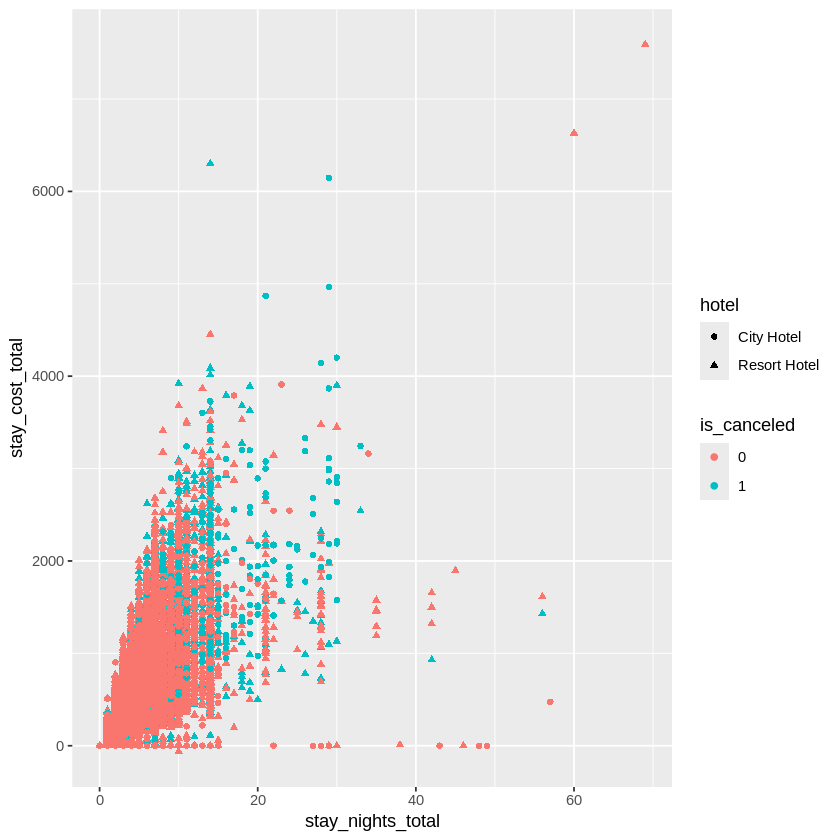

In [16]:
#scatter plots with total nights and total cost
ggplot(hotel_data, aes(x=stay_nights_total,y=stay_cost_total,shape=hotel,color=is_canceled))+
  geom_point(alpha=1)

### Biểu đồ Facet plot:

Tương tự như scatter plot nhưng được chia nhỏ theo các phân khúc thị trường khác nhau.

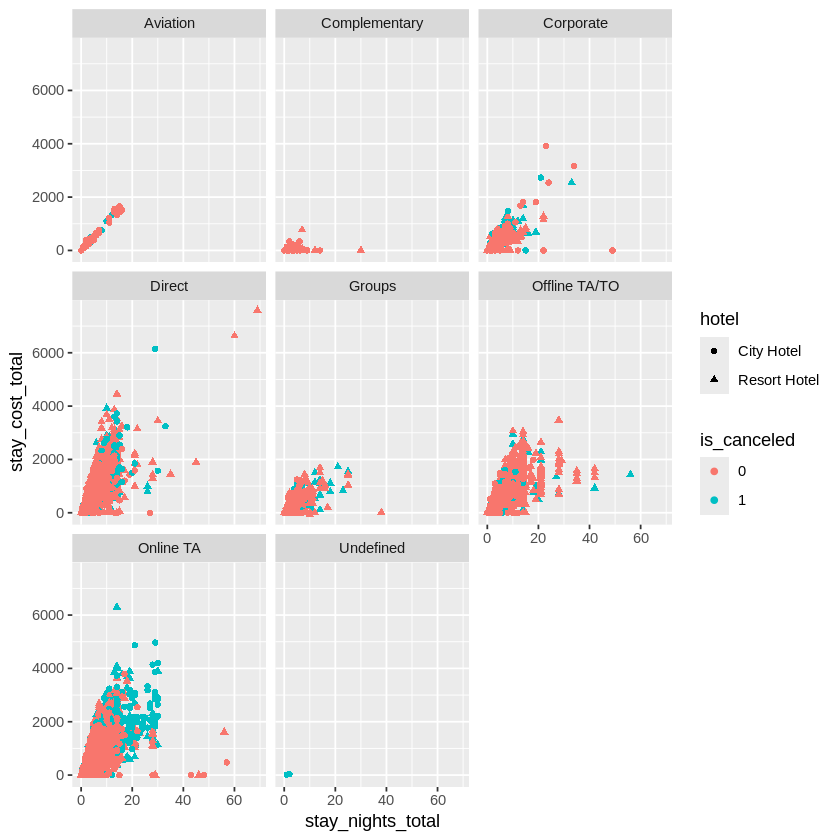

In [ ]:
#Exploring the data across different market segments
ggplot(hotel_data, aes(x=stay_nights_total,y=stay_cost_total,shape=hotel,color=is_canceled))+
  geom_point()+
  facet_wrap(~market_segment)

Comparison of year of Arrival date versus cancellation, year 2016 is the one with the most bookings as well as cancellations

### Biểu đồ Bar plot:

So sánh số lượng đặt phòng và số lượng hủy phòng theo năm đến, theo loại khách sạn, theo loại phòng được chỉ định và theo kênh phân phối

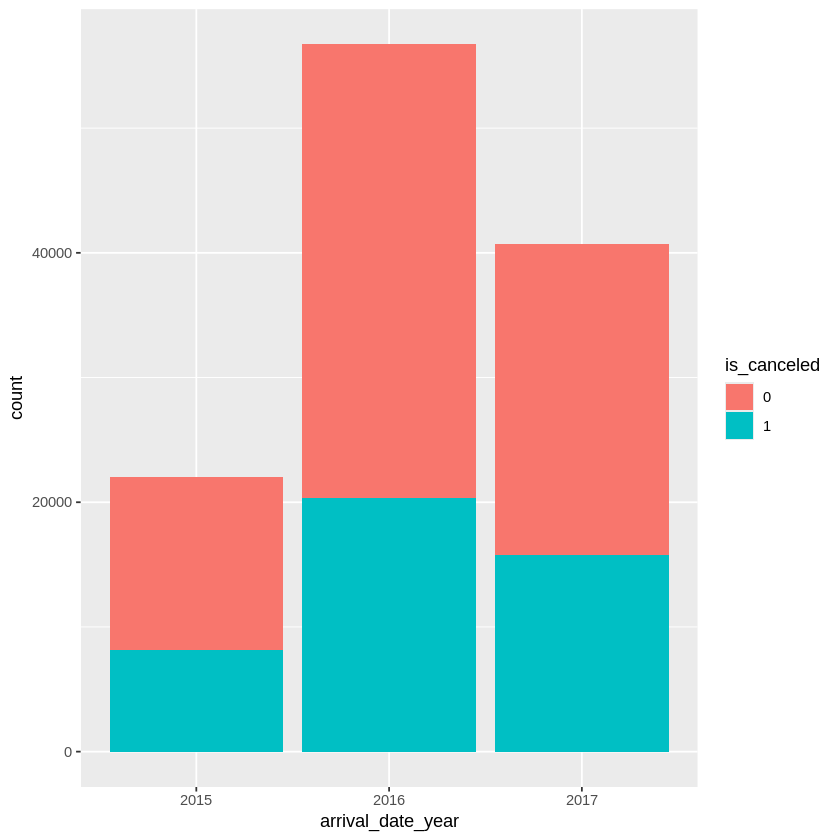

In [ ]:

hotel_data%>%
  ggplot(aes(x=arrival_date_year,fill=is_canceled))+
  geom_bar()

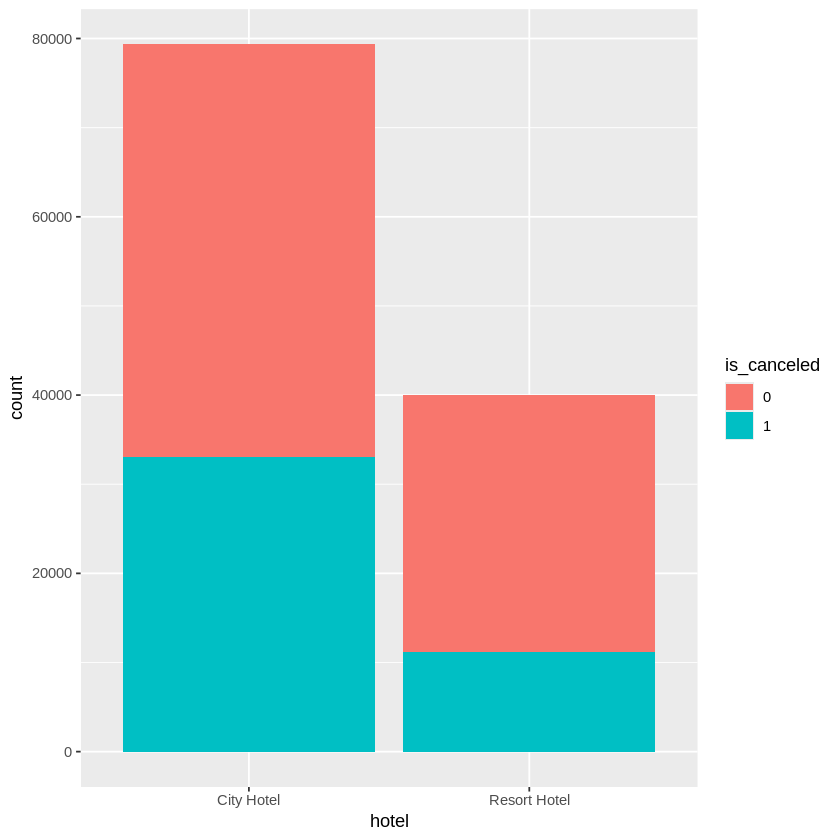

In [ ]:
#Box Plot of hotel types

hotel_data%>%
  ggplot(aes(x=hotel,fill=is_canceled))+
  geom_bar()

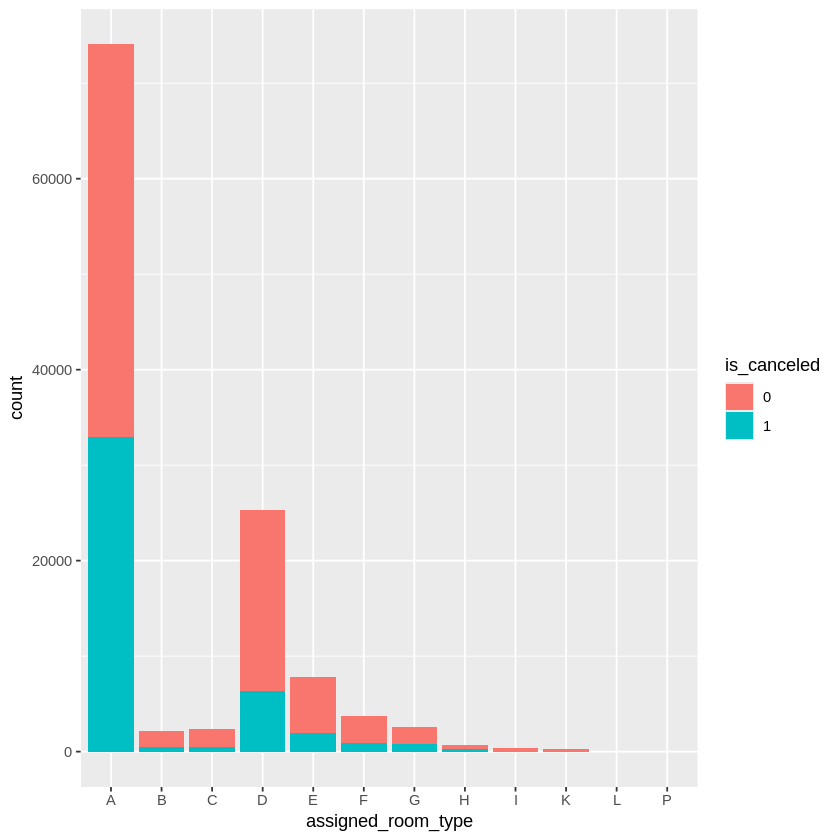

In [ ]:
#Assigned room type
hotel_data%>%
  ggplot(aes(x=assigned_room_type,fill=is_canceled))+
  geom_bar()

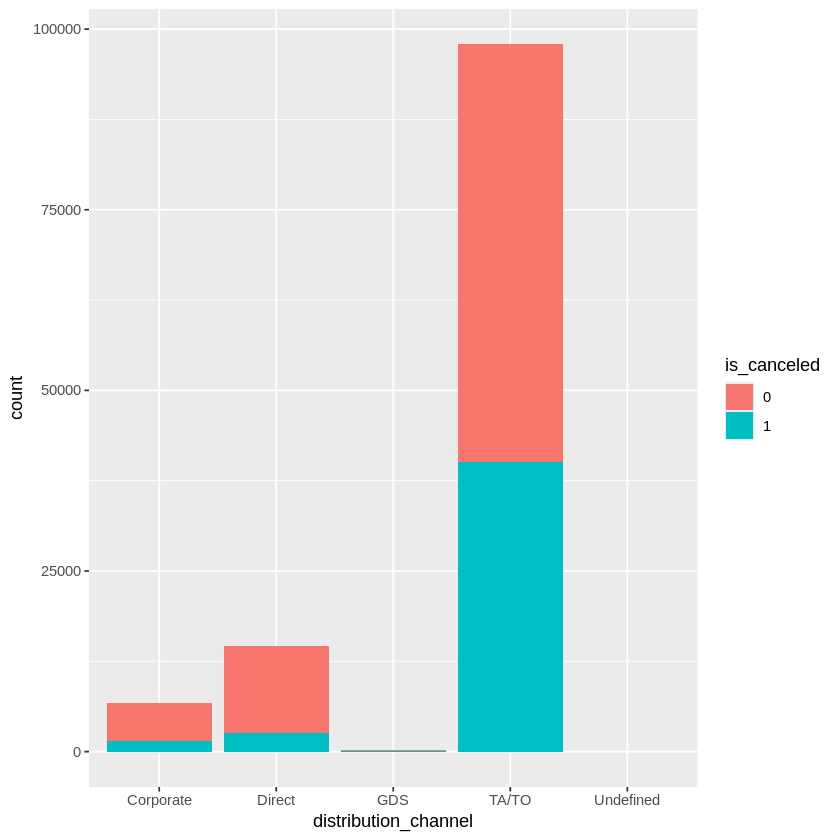

In [ ]:
#Distribution channel
hotel_data%>%
  ggplot(aes(x=distribution_channel,fill=is_canceled))+
  geom_bar()

### Biểu đồ Histogram:

thể hiện phân phối của số ngày trong danh sách chờ và số lượng hủy phòng, cũng như phân phối của thời gian chờ (lead time) và số lượng hủy phòng.

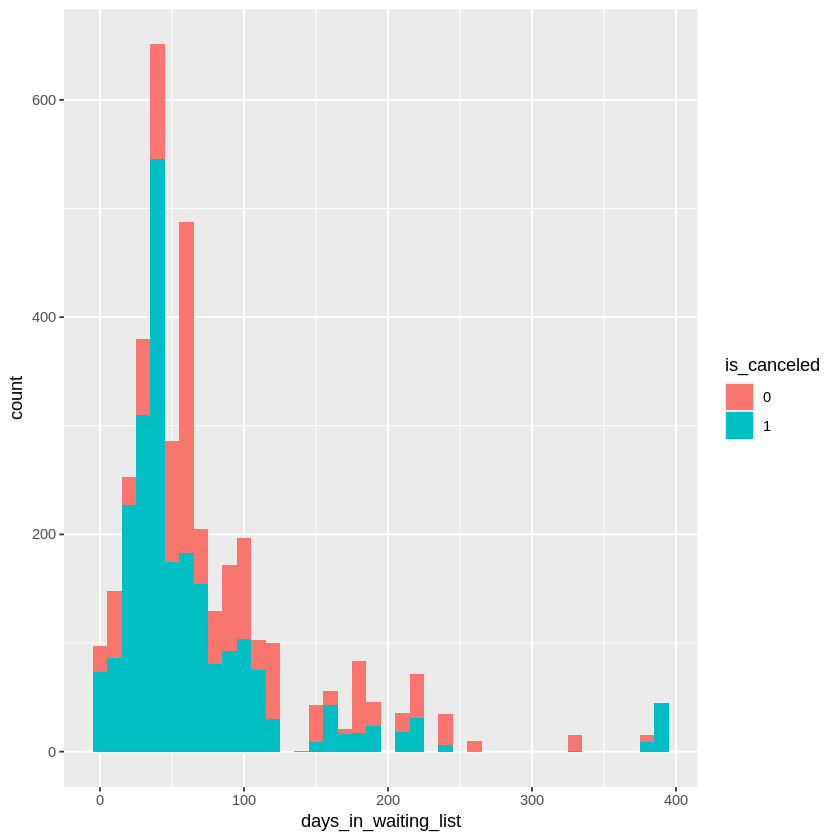

In [ ]:
#Histogram illustrating Days in waiting list and cancellations
hotel_data%>%
  filter(days_in_waiting_list>1)%>%
  ggplot(aes(x=days_in_waiting_list,fill=is_canceled))+
  geom_histogram(binwidth = 10)

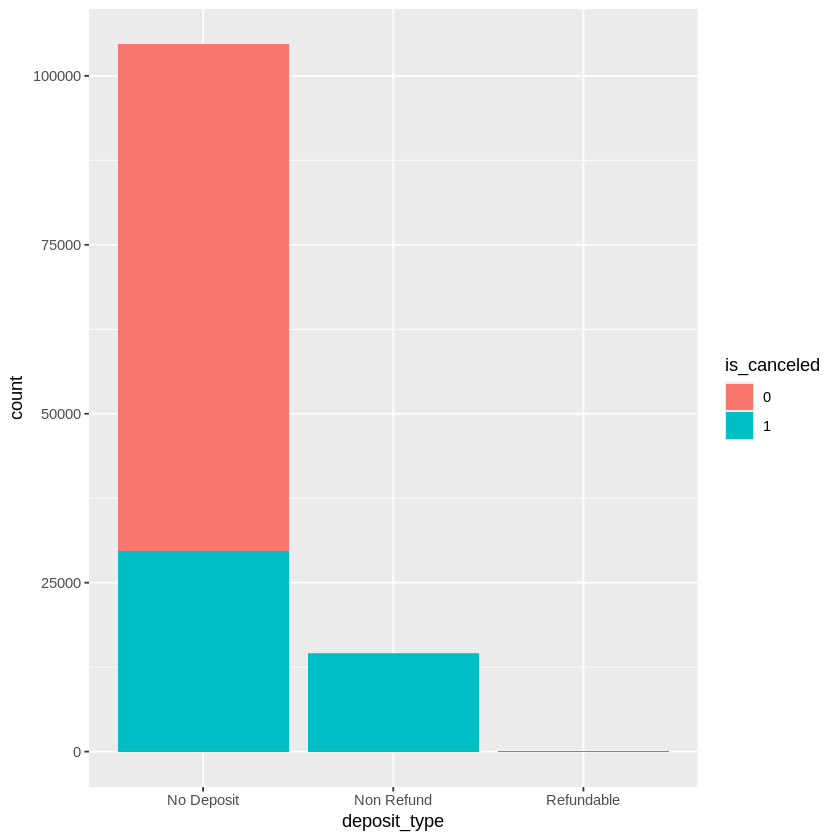

In [ ]:
hotel_data%>%
  ggplot(aes(x=deposit_type,fill=is_canceled))+
  geom_bar()

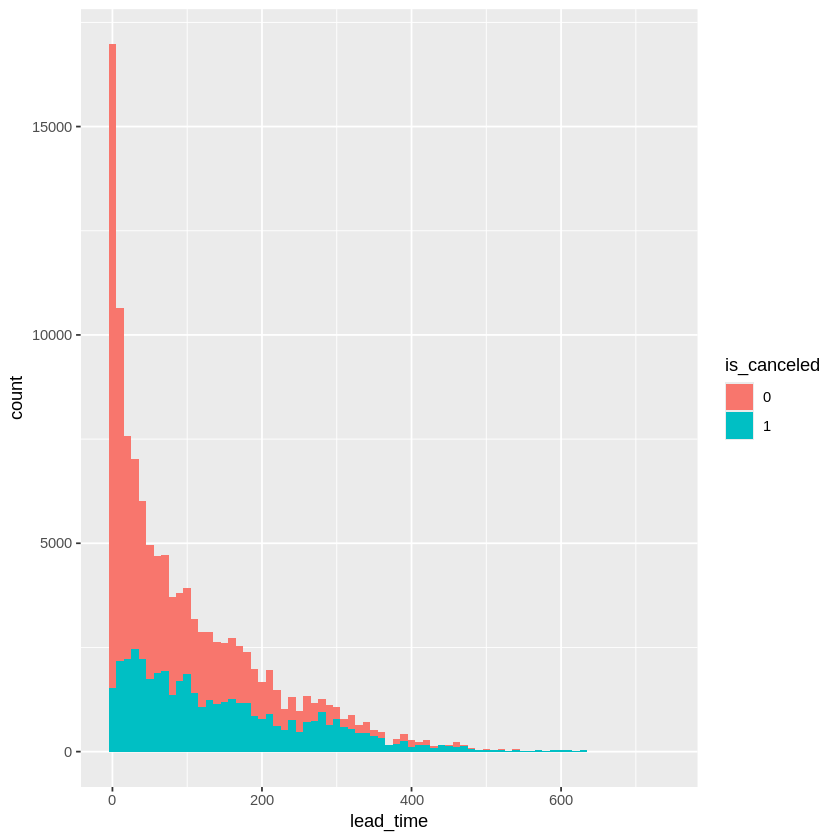

In [ ]:
#Lead time and hotel cancellations
hotel_data%>%
  ggplot(aes(x=lead_time,fill=is_canceled))+
  geom_histogram(binwidth=10,position="stack")


## 4.  Mô hình hóa dữ liệu

### Chia dữ liệu thành tập huấn luyện và tập kiểm tra

In [16]:
set.seed(1)   # set a random seed
index <- sample(nrow(hotel_data), nrow(hotel_data)*0.3) # random selection of indices.

hotel_data <- hotel_data %>%
              filter(market_segment!='Undefined')

test <- hotel_data[index,]       # save 30% as a test dataset
training <-hotel_data[-index,]   # save the rest as a training set

Based on our initial analysis lets start our modeling with 21 varaibles due to the large nature of the dataset

In [17]:
training_1 <- training[c('hotel','is_canceled','lead_time','adults','children','babies','meal',
                         'market_segment','distribution_channel','is_repeated_guest',
                         'previous_cancellations','previous_bookings_not_canceled','reserved_room_type',
                         'deposit_type','days_in_waiting_list','customer_type','adr',
                         'required_car_parking_spaces','stay_nights_total','stay_cost_total')]



In [26]:
head(training_1)

hotel,is_canceled,lead_time,adults,children,babies,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,stay_nights_total,stay_cost_total
<fct>,<fct>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<int>,<int>,<fct>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<dbl>
Resort Hotel,0,737,2,0,0,BB,Direct,Direct,0,0,0,C,No Deposit,0,Transient,0,0,0,0
Resort Hotel,0,7,1,0,0,BB,Direct,Direct,0,0,0,A,No Deposit,0,Transient,75,0,1,75
Resort Hotel,0,13,1,0,0,BB,Corporate,Corporate,0,0,0,A,No Deposit,0,Transient,75,0,1,75
Resort Hotel,0,14,2,0,0,BB,Online TA,TA/TO,0,0,0,A,No Deposit,0,Transient,98,0,2,196
Resort Hotel,0,14,2,0,0,BB,Online TA,TA/TO,0,0,0,A,No Deposit,0,Transient,98,0,2,196
Resort Hotel,1,85,2,0,0,BB,Online TA,TA/TO,0,0,0,A,No Deposit,0,Transient,82,0,3,246


### Xây dựng mô hình Logistic Regression:

In [18]:
logit_training_model<-glm(is_canceled~.,family="binomial",data=training_1)
summary(logit_training_model)

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = is_canceled ~ ., family = "binomial", data = training_1)

Coefficients:
                                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)                    -2.562e+00  2.081e-01 -12.314  < 2e-16 ***
hotelResort Hotel               1.303e-02  2.312e-02   0.563 0.573135    
lead_time                       3.254e-03  1.061e-04  30.655  < 2e-16 ***
adults                          9.344e-02  1.732e-02   5.394 6.88e-08 ***
children                        1.183e-01  2.774e-02   4.263 2.01e-05 ***
babies                         -5.668e-01  1.101e-01  -5.148 2.63e-07 ***
mealFB                          8.420e-01  1.240e-01   6.793 1.10e-11 ***
mealHB                         -1.737e-01  3.143e-02  -5.529 3.22e-08 ***
mealSC                          1.786e-01  2.981e-02   5.990 2.10e-09 ***
mealUndefined                  -4.342e-01  1.163e-01  -3.734 0.000189 ***
market_segmentComplementary    -2.278e-01  2.662e-01  -0.856 0.391976    
market_segmentCorpo

In [19]:

test$logit_pred_prob<-predict(logit_training_model,test,type="response")
test$logit_pred_class<-ifelse(test$logit_pred_prob>0.5,"1","0")

table(test$is_canceled==test$logit_pred_class)


FALSE  TRUE 
 7875 27939 

In [20]:

table(test$logit_pred_class,test$is_canceled, dnn=c("predicted","actual"))

         actual
predicted     0     1
        0 21650  6982
        1   893  6289

In [21]:
27939/nrow(test)

[1] 0.7800486

In [23]:

conf_matrix <- table(test$logit_pred_class, test$is_canceled)

# Extract TP, TN, FP, FN
TP <- conf_matrix[2,2]
TN <- conf_matrix[1,1]
FP <- conf_matrix[2,1]
FN <- conf_matrix[1,2]


# Calculate Precision, Recall, and F1-score
precision <- TP / (TP + FP)
recall <- TP / (TP + FN)
f1_score <- 2 * (precision * recall) / (precision + recall)

# Print the results
cat("Precision:", precision, "\n")
cat("Recall:", recall, "\n")
cat("F1-score:", f1_score, "\n")
cat("Acurracy:", 27939/nrow(test), "\n")

Precision: 0.8756614 
Recall: 0.4738904 
F1-score: 0.6149709 
Acurracy: 0.7800486 


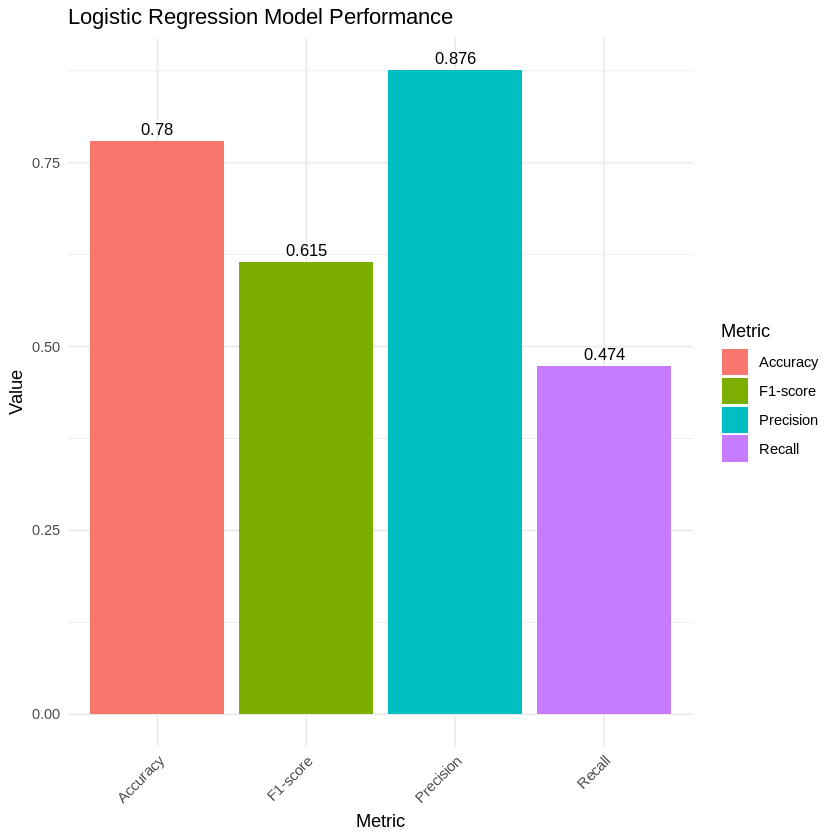

In [24]:
# Create a data frame for the metrics
metrics_data <- data.frame(
  Metric = c("Precision", "Recall", "F1-score", "Accuracy"),
  Value = c(0.8756614, 0.4738904, 0.6149709, 0.7800486)
)

# Create the bar chart using ggplot2
library(ggplot2)

ggplot(metrics_data, aes(x = Metric, y = Value, fill = Metric)) +
  geom_col() +  # Use geom_col for bar chart
  geom_text(aes(label = round(Value, 3)), vjust = -0.5, size = 3.5) + # Add value labels
  labs(title = "Logistic Regression Model Performance",
       x = "Metric", y = "Value") +
  theme_minimal() +  # Use a clean theme
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) # Rotate x-axis labels

### Xây dựng mô hình Naive Bayes Model

In [26]:
install.packages("e1071")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’




In [27]:
library(e1071)

model_nb = naiveBayes(is_canceled ~ ., data = training_1)

model_nb


Naive Bayes Classifier for Discrete Predictors

Call:
naiveBayes.default(x = X, y = Y, laplace = laplace)

A-priori probabilities:
Y
        0         1 
0.6296726 0.3703274 

Conditional probabilities:
   hotel
Y   City Hotel Resort Hotel
  0  0.6137620    0.3862380
  1  0.7473586    0.2526414

   lead_time
Y        [,1]      [,2]
  0  79.76503  91.00095
  1 144.68312 118.44407

   adults
Y       [,1]      [,2]
  0 1.828763 0.5095713
  1 1.902549 0.6522965

   children
Y        [,1]      [,2]
  0 0.1026547 0.3915963
  1 0.1067563 0.4089315

   babies
Y         [,1]       [,2]
  0 0.01090778 0.11952255
  1 0.00371579 0.06137367

   meal
Y            BB          FB          HB          SC   Undefined
  0 0.768390248 0.004199685 0.126750660 0.089143530 0.011515877
  1 0.780445249 0.011244305 0.111473715 0.090019064 0.006817668

   market_segment
Y      Aviation Complementary   Corporate      Direct      Groups Offline TA/TO
  0 0.002622427   0.008570397 0.058434525 0.142067157 0.1024837

In [28]:
pred_nb = predict(model_nb, as.data.frame(test))
pred_prob_nb = predict(model_nb, as.data.frame(test), type = "raw")

table(pred_nb,test$is_canceled, dnn=c("predicted","actual"))

         actual
predicted     0     1
        0  2922   135
        1 19621 13138

In [30]:
(2922+13138)/nrow(test)

[1] 0.4483904

In [31]:
# Calculate the confusion matrix
conf_matrix_nb <- table(pred_nb, test$is_canceled)

# Extract TP, TN, FP, FN for Naive Bayes
TP_nb <- conf_matrix_nb[2,2]
TN_nb <- conf_matrix_nb[1,1]
FP_nb <- conf_matrix_nb[2,1]
FN_nb <- conf_matrix_nb[1,2]

# Calculate Precision, Recall, and F1-score for Naive Bayes
precision_nb <- TP_nb / (TP_nb + FP_nb)
recall_nb <- TP_nb / (TP_nb + FN_nb)
f1_score_nb <- 2 * (precision_nb * recall_nb) / (precision_nb + recall_nb)
accuracy_nb <- (2922+13138)/nrow(test)

# Print the results for Naive Bayes
cat("Naive Bayes - Precision:", precision_nb, "\n")
cat("Naive Bayes - Recall:", recall_nb, "\n")
cat("Naive Bayes - F1-score:", f1_score_nb, "\n")
cat("Naive Bayes - Accuracy:", accuracy_nb, "\n")


Naive Bayes - Precision: 0.4010501 
Naive Bayes - Recall: 0.989829 
Naive Bayes - F1-score: 0.5708203 
Naive Bayes - Accuracy: 0.4483904 


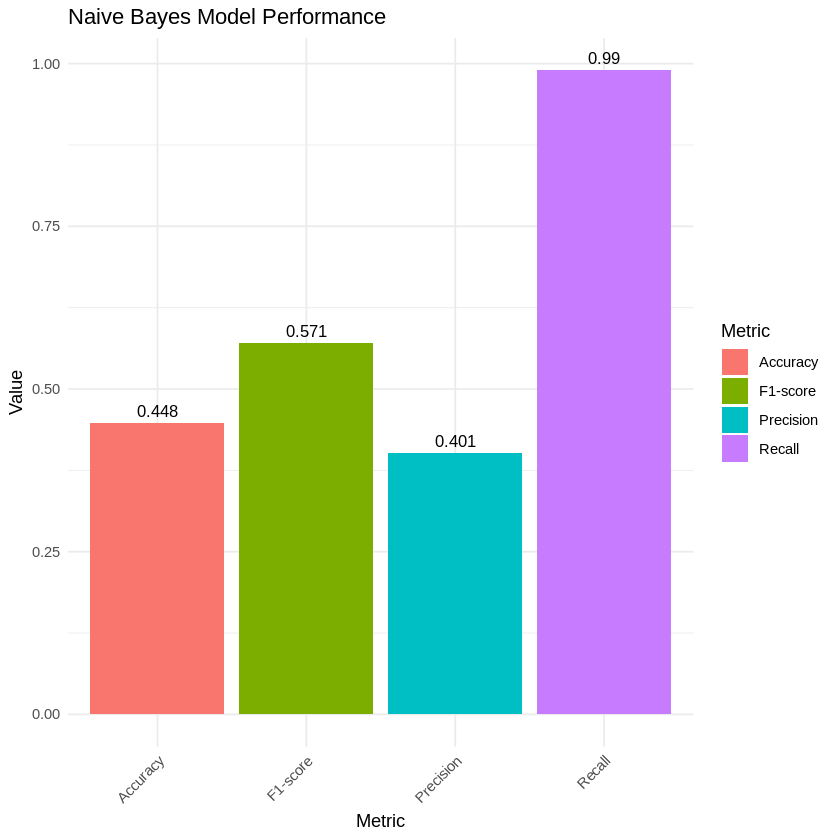

In [33]:
#BIỂU ĐỒ TRỰC QUAN HÓA CHO
# Naive Bayes - Precision: 0.4010501
# Naive Bayes - Recall: 0.989829
# Naive Bayes - F1-score: 0.5708203
# Naive Bayes - Accuracy: 0.4483904

# Create a data frame for the Naive Bayes metrics
metrics_data_nb <- data.frame(
  Metric = c("Precision", "Recall", "F1-score", "Accuracy"),
  Value = c(precision_nb, recall_nb, f1_score_nb, accuracy_nb)
)

# Create the bar chart using ggplot2 for Naive Bayes
ggplot(metrics_data_nb, aes(x = Metric, y = Value, fill = Metric)) +
  geom_col() +  # Use geom_col for bar chart
  geom_text(aes(label = round(Value, 3)), vjust = -0.5, size = 3.5) + # Add value labels
  labs(title = "Naive Bayes Model Performance",
       x = "Metric", y = "Value") +
  theme_minimal() +  # Use a clean theme
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) # Rotate x-axis labels

### Xây dựng mô hình Decision Tree

In [34]:
install.packages("rpart.plot")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



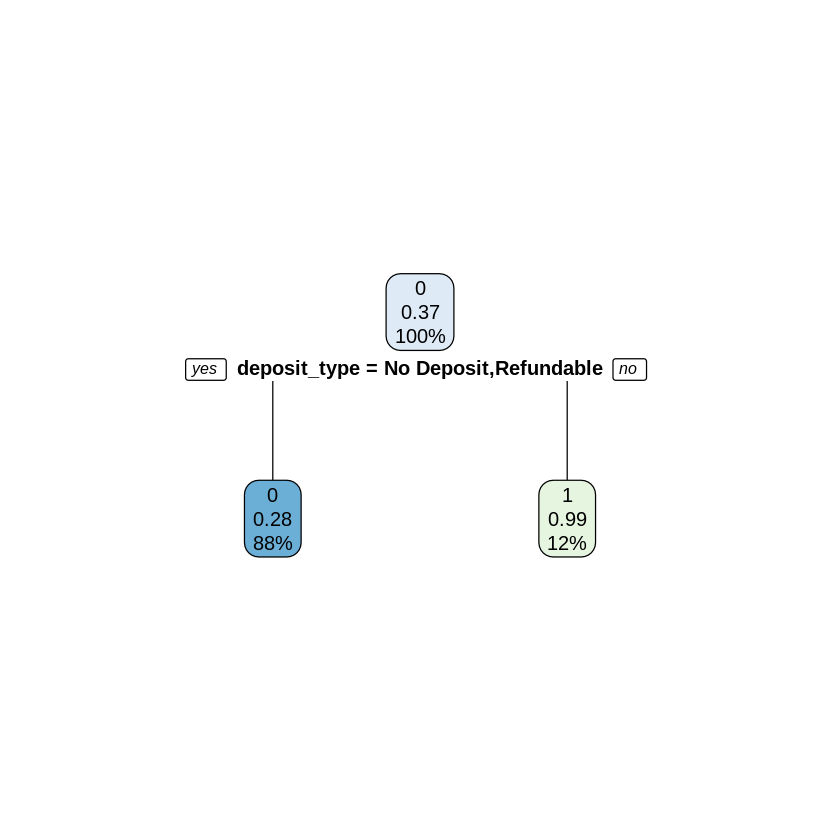

In [35]:
library(rpart)   #Decision Tree
library(rpart.plot)
training_model<-rpart(is_canceled~.,
                      data=training_1,
                      method="class",
                      control=rpart.control(cp=0.03))

rpart.plot(training_model)

In [36]:
# Accuracy of the model
test$ct_pred_prob<-predict(training_model,test)[,2]
test$ct_pred_class<-predict(training_model,test,type="class")


table(test$is_canceled==test$ct_pred_class)


FALSE  TRUE 
 8940 26876 


Classification tree:
rpart(formula = is_canceled ~ ., data = training_1, method = "class", 
    control = rpart.control(cp = 0, maxdepth = 3))

Variables actually used in tree construction:
[1] deposit_type                   lead_time                     
[3] previous_bookings_not_canceled previous_cancellations        

Root node error: 30949/83572 = 0.37033

n= 83572 

          CP nsplit rel error  xerror      xstd
1 0.32530938      0   1.00000 1.00000 0.0045106
2 0.02200394      1   0.67469 0.67469 0.0040439
3 0.00016156      3   0.63068 0.65608 0.0040060
4 0.00000000      4   0.63052 0.65582 0.0040055


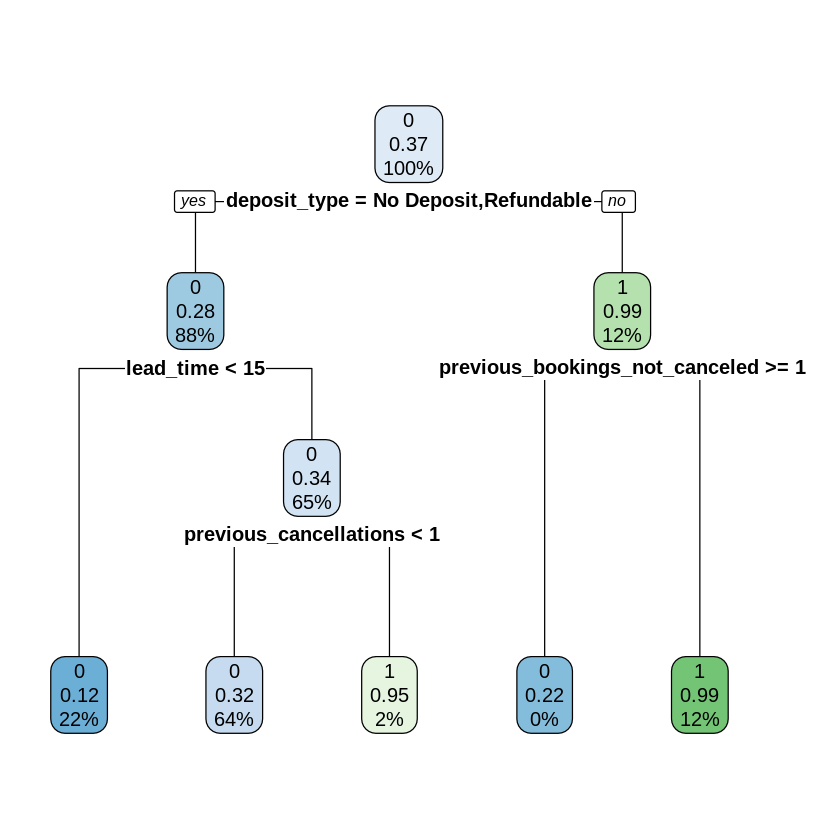

In [37]:
#k-cross validation
set.seed(1)   # set a random seed
full_tree<-rpart(is_canceled~.,
                     data=training_1,
                     method="class",
                     control=rpart.control(cp=0, maxdepth = 3))

rpart.plot(full_tree)



printcp(full_tree)   # xerror, xstd - cross validation results

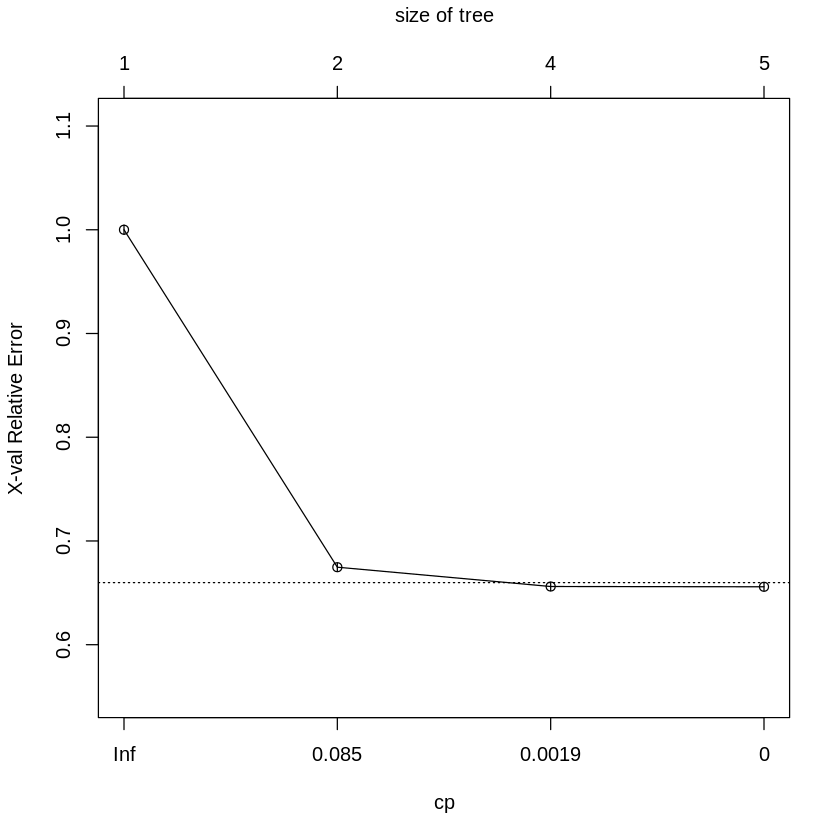

In [38]:
plotcp(full_tree)

CP      nsplit   rel error      xerror        xstd 
0.000000000 4.000000000 0.630521180 0.655820867 0.004005484

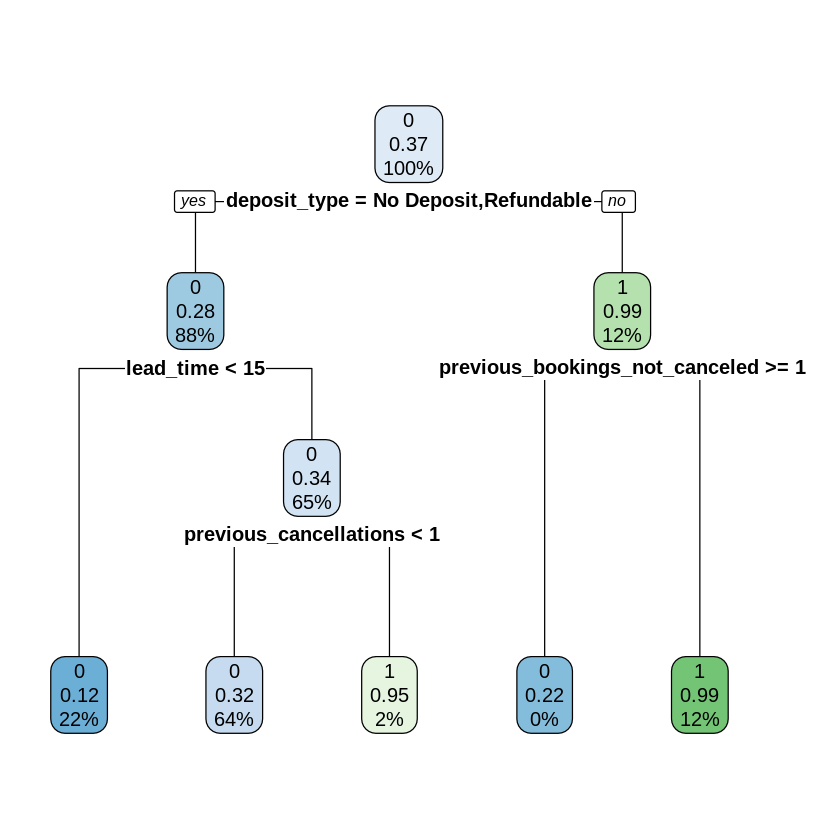

In [39]:
min_xerror<-full_tree$cptable[which.min(full_tree$cptable[,"xerror"]),]
min_xerror

# prune tree with minimum cp value
min_xerror_tree<-prune(full_tree, cp=min_xerror[1])
rpart.plot(min_xerror_tree)

In [40]:
#Accuracy of pruned tree
bp_tree<-min_xerror_tree
test$ct_bp_pred_prob<-predict(bp_tree,test)[,2]
test$ct_bp_pred_class=ifelse(test$ct_bp_pred_prob>0.5,"Yes","No")

table(test$ct_bp_pred_class,test$is_canceled, dnn=c("predicted","actual"))

         actual
predicted     0     1
      No  22486  8309
      Yes    57  4964

In [41]:
(22486+4964)/nrow(test)

[1] 0.7663958

In [43]:
# Calculate the confusion matrix for the decision tree
conf_matrix_dt <- table(test$ct_bp_pred_class, test$is_canceled)

# Extract TP, TN, FP, FN for the decision tree
TP_dt <- conf_matrix_dt["Yes", "1"]
TN_dt <- conf_matrix_dt["No", "0"]
FP_dt <- conf_matrix_dt["Yes", "0"]
FN_dt <- conf_matrix_dt["No", "1"]

# Calculate Precision, Recall, and F1-score for the decision tree
precision_dt <- TP_dt / (TP_dt + FP_dt)
recall_dt <- TP_dt / (TP_dt + FN_dt)
f1_score_dt <- 2 * (precision_dt * recall_dt) / (precision_dt + recall_dt)
accuracy_dt <- (22486 + 4964) / nrow(test)

# Print the results for the decision tree
cat("Decision Tree - Precision:", precision_dt, "\n")
cat("Decision Tree - Recall:", recall_dt, "\n")
cat("Decision Tree - F1-score:", f1_score_dt, "\n")
cat("Decision Tree - Accuracy:", accuracy_dt, "\n")

Decision Tree - Precision: 0.9886477 
Decision Tree - Recall: 0.3739923 
Decision Tree - F1-score: 0.5426916 
Decision Tree - Accuracy: 0.7663958 


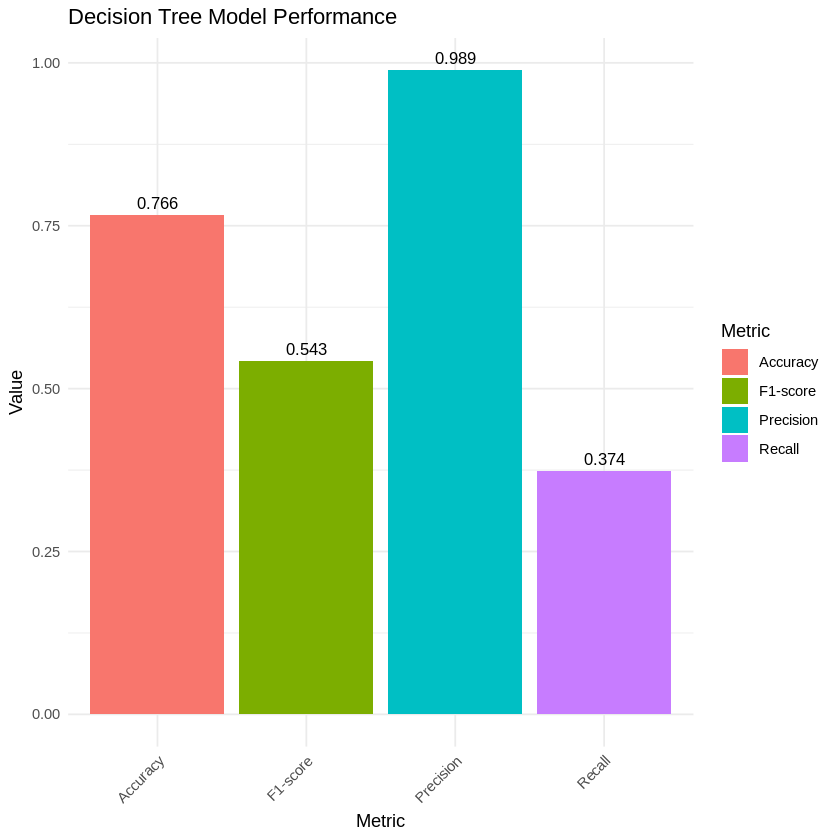

In [44]:

# Create a data frame for the Decision Tree metrics
metrics_data_dt <- data.frame(
  Metric = c("Precision", "Recall", "F1-score", "Accuracy"),
  Value = c(precision_dt, recall_dt, f1_score_dt, accuracy_dt)
)

# Create the bar chart using ggplot2 for Decision Tree
ggplot(metrics_data_dt, aes(x = Metric, y = Value, fill = Metric)) +
  geom_col() +  # Use geom_col for bar chart
  geom_text(aes(label = round(Value, 3)), vjust = -0.5, size = 3.5) + # Add value labels
  labs(title = "Decision Tree Model Performance",
       x = "Metric", y = "Value") +
  theme_minimal() +  # Use a clean theme
theme(axis.text.x = element_text(angle = 45, hjust = 1)) # Fixed: Added hjust = 1

### Xây dựng mô hình  Random Forest

In [46]:
 install.packages("randomForest")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [47]:
library(randomForest)
set.seed(1)
rf_training_model<-randomForest(is_canceled~.,    # model formula
                       data=training_1,          # use a training dataset for building a model
                       ntree=500,
                       cutoff=c(0.5,0.5),
                       mtry=2,
                       importance=TRUE)
rf_training_model

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin





Call:
 randomForest(formula = is_canceled ~ ., data = training_1, ntree = 500,      cutoff = c(0.5, 0.5), mtry = 2, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 2

        OOB estimate of  error rate: 21.79%
Confusion matrix:
      0     1 class.error
0 51977   646   0.0122760
1 17565 13384   0.5675466

In [48]:
29451/nrow(test)

[1] 0.8222632

In [51]:
# prompt: tính và in ra các dộ đo "Precision", "Recall", "F1-score", "Accuracy" cho mô hình random forest - rf_training_model

# Predict on the test set
rf_predictions <- predict(rf_training_model, newdata = test)

# Create the confusion matrix
conf_matrix_rf <- table(rf_predictions, test$is_canceled)

# Extract TP, TN, FP, FN for the random forest model
TP_rf <- conf_matrix_rf["1", "1"]
TN_rf <- conf_matrix_rf["0", "0"]
FP_rf <- conf_matrix_rf["1", "0"]
FN_rf <- conf_matrix_rf["0", "1"]

# Calculate Precision, Recall, F1-score, and Accuracy
precision_rf <- TP_rf / (TP_rf + FP_rf)
recall_rf <- TP_rf / (TP_rf + FN_rf)
f1_score_rf <- 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf)
accuracy_rf <- (TP_rf + TN_rf) / (TP_rf + TN_rf + FP_rf + FN_rf)

# Print the results
cat("Random Forest - Precision:", precision_rf, "\n")
cat("Random Forest - Recall:", recall_rf, "\n")
cat("Random Forest - F1-score:", f1_score_rf, "\n")
cat("Random Forest - Accuracy:", accuracy_rf, "\n")

Random Forest - Precision: 0.9532048 
Random Forest - Recall: 0.4359129 
Random Forest - F1-score: 0.598242 
Random Forest - Accuracy: 0.7830457 


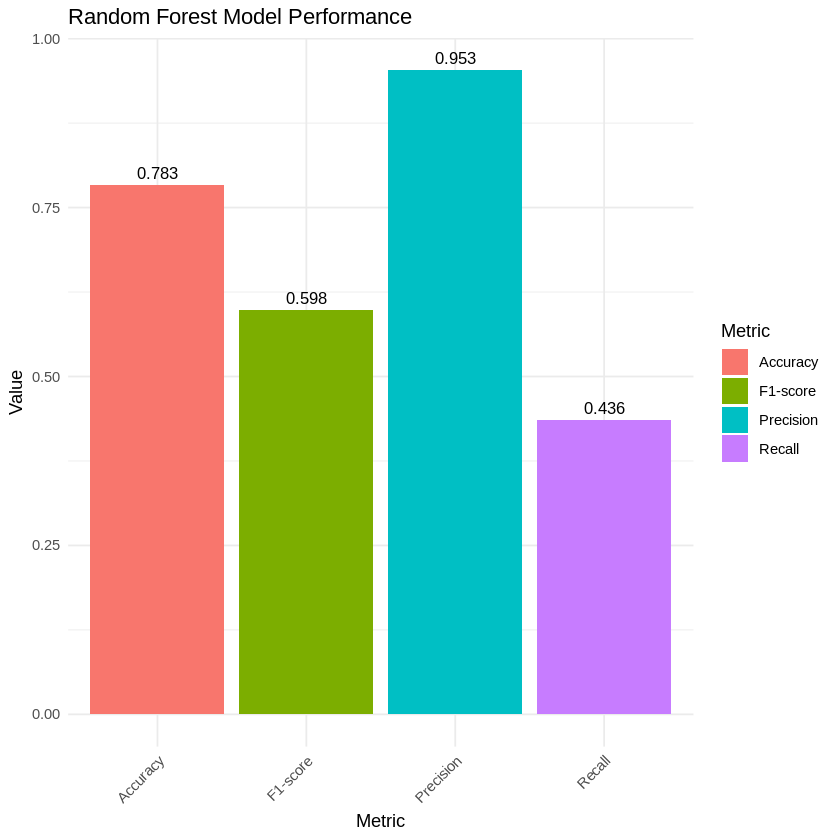

In [53]:
# Assuming you have already calculated the metrics and stored them in variables:
# precision_rf, recall_rf, f1_score_rf, accuracy_rf

# Create a data frame for the metrics
rf_metrics <- data.frame(
  Metric = c("Precision", "Recall", "F1-score", "Accuracy"),
  Value = c(precision_rf, recall_rf, f1_score_rf, accuracy_rf)
)

# Create the bar chart using ggplot2
library(ggplot2)

ggplot(rf_metrics, aes(x = Metric, y = Value, fill = Metric)) +
  geom_col() +  # Use geom_col for bar chart
  geom_text(aes(label = round(Value, 3)), vjust = -0.5, size = 3.5) + # Add value labels
  labs(title = "Random Forest Model Performance",
       x = "Metric", y = "Value") +
  theme_minimal() +  # Use a clean theme
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) # Rotate x-axis labels for better readability

# Đánh giá mô hình:

## Biểu đồ cột so sánh các chỉ số đánh giá cho các mô hình

In [ ]:
install.packages("reshape2")
library(reshape2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




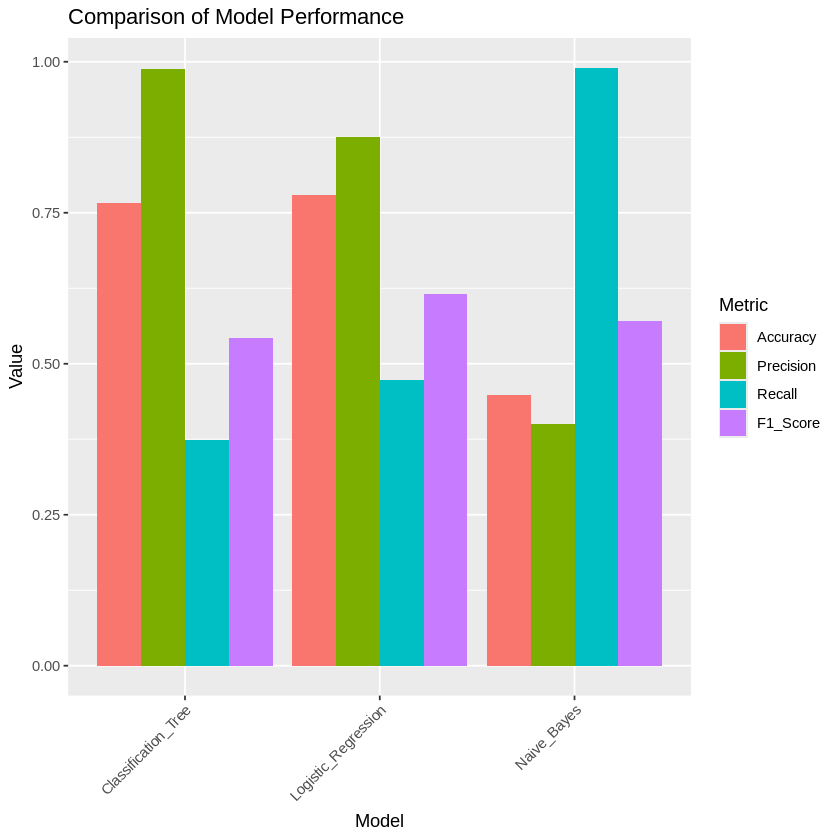

In [ ]:
# Function to calculate metrics
calculate_metrics <- function(predicted, actual) {
  cm <- table(predicted, actual, dnn=c("predicted","actual"))
  accuracy <- sum(diag(cm)) / sum(cm)
  precision <- cm[2,2] / sum(cm[2,]) # Positive class precision
  recall <- cm[2,2] / sum(cm[,2]) # Positive class recall
  f1_score <- 2 * (precision * recall) / (precision + recall)
  return(list(accuracy = accuracy, precision = precision, recall = recall, f1_score = f1_score))
}

# Calculate metrics for each model
models <- list(
  Logistic_Regression = list(predicted = test$logit_pred_class, actual = test$is_canceled),
  Naive_Bayes = list(predicted = pred_nb, actual = test$is_canceled),
  Classification_Tree = list(predicted = test$ct_bp_pred_class, actual = test$is_canceled)
)

# Store metrics in a data frame
model_metrics <- data.frame()
for (model_name in names(models)) {
  metrics <- calculate_metrics(models[[model_name]]$predicted, models[[model_name]]$actual)
  model_metrics <- rbind(model_metrics, data.frame(Model = model_name,
                                                   Accuracy = metrics$accuracy,
                                                   Precision = metrics$precision,
                                                   Recall = metrics$recall,
                                                   F1_Score = metrics$f1_score))
}

# Reshape data for plotting
library(reshape2)
melted_metrics <- melt(model_metrics, id.vars = "Model", variable.name = "Metric")

# Create bar plot using ggplot2
library(ggplot2)
ggplot(melted_metrics, aes(x = Model, y = value, fill = Metric)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Comparison of Model Performance",
       x = "Model", y = "Value") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## Trực quan hóa kết quả bằng ROC curve và AUC

### Plotting ROC curves

In [ ]:
install.packages("pROC")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’




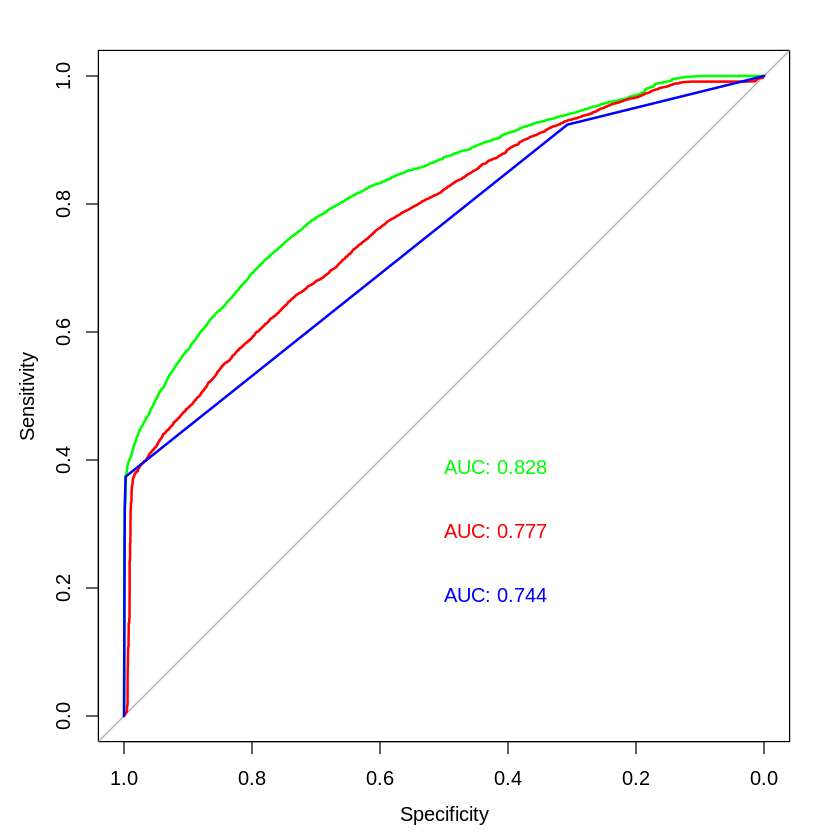

In [ ]:

library(pROC)
plot(logit_roc,print.auc=TRUE,print.auc.y=.4, col="green")
plot(nb_roc,print.auc=TRUE,print.auc.y=.3, col="red",add=TRUE)
plot(ct_roc,print.auc=TRUE,print.auc.y=.2, col="blue",add=TRUE)


### AUC values

In [ ]:
# Print AUC values
print(paste("Logistic Regression AUC:", auc(logit_roc)))
print(paste("Naive Bayes AUC:", auc(nb_roc)))
print(paste("Classification Tree AUC:", auc(ct_roc)))

# Find the model with the highest AUC
best_model <- which.max(c(auc(logit_roc), auc(nb_roc), auc(ct_roc)))
model_names <- c("Logistic Regression", "Naive Bayes", "Classification Tree")
print(paste("Best model:", model_names[best_model]))

[1] "Logistic Regression AUC: 0.828184569498612"
[1] "Naive Bayes AUC: 0.777134131087027"
[1] "Classification Tree AUC: 0.744180636004545"
[1] "Best model: Logistic Regression"


## **KẾT LUẬN: MÔ HÌNH Logistic Regression LÀ TỐT NHẤT**